# Team505 — Exploratory Data Analysis
 DSAI 305 | NIH ChestX-ray14 | Binary Pneumonia Detection

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path('..').resolve()
DATA_SPLITS  = PROJECT_ROOT / 'data' / 'splits'
DATA_RAW     = PROJECT_ROOT / 'data' / 'raw'
EDA_OUTPUT   = PROJECT_ROOT / 'outputs' / 'eda'
EDA_OUTPUT.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
print(f'EDA output dir: {EDA_OUTPUT}')

EDA output dir: C:\ChestX-ray14\Team505_phase2\outputs\eda


## 1 — Load Splits

In [35]:
df_train = pd.read_csv(DATA_SPLITS / 'train.csv')
df_val   = pd.read_csv(DATA_SPLITS / 'val.csv')
df_test  = pd.read_csv(DATA_SPLITS / 'test.csv')

# Normalize column names
for _df in [df_train, df_val, df_test]:
    if 'label' in _df.columns and 'target_pneumonia' not in _df.columns:
        _df['target_pneumonia'] = _df['label']
    if 'patient_id' not in _df.columns and 'pid_str' in _df.columns:
        _df['patient_id'] = _df['pid_str']

df_all   = pd.concat([df_train, df_val, df_test], ignore_index=True)

try:
    df_meta = pd.read_csv(DATA_RAW / 'Data_Entry_2017.csv')
    print(f'Loaded NIH metadata: {len(df_meta):,} rows')
except FileNotFoundError:
    df_meta = None
    print('NIH metadata not found.')

print(f'Total dataset: {len(df_all):,} images')
print(f'Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}')


Loaded NIH metadata: 112,120 rows
Total dataset: 17,172 images
Train: 11,943 | Val: 2,611 | Test: 2,618


## 2 — Dataset Overview

In [36]:
splits_info = [
    ('Train', df_train),
    ('Val',   df_val),
    ('Test',  df_test),
]


## 3 — Class Imbalance Analysis

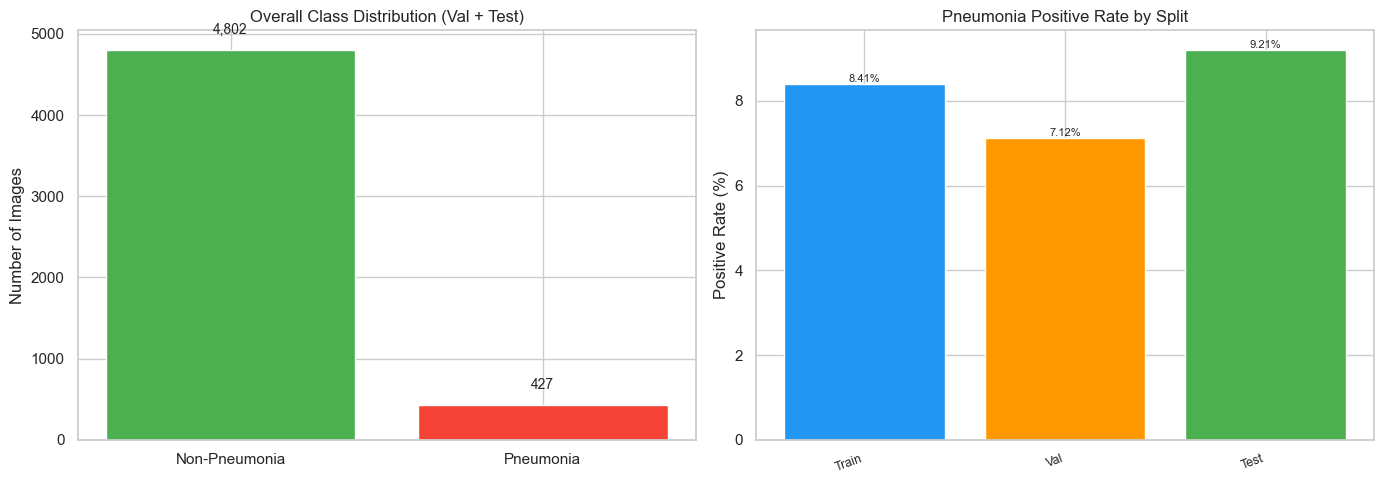

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
ax = axes[0]
labels_plot = ['Non-Pneumonia', 'Pneumonia']
counts_plot = [
    int(df_val['target_pneumonia'].eq(0).sum()) +
    int(df_test['target_pneumonia'].eq(0).sum()),
    int(df_val['target_pneumonia'].sum()) +
    int(df_test['target_pneumonia'].sum()),
]
colors = ['#4CAF50', '#F44336']
ax.bar(labels_plot, counts_plot, color=colors)
for i, v in enumerate(counts_plot):
    ax.text(i, v + 200, f'{v:,}', ha='center', fontsize=10)
ax.set_title('Overall Class Distribution (Val + Test)')
ax.set_ylabel('Number of Images')

# Class distribution by split
ax = axes[1]
split_names = [s[0] for s in splits_info]
pos_rates   = [df['target_pneumonia'].mean()*100 for _, df in splits_info]
bar_colors  = ['#2196F3','#FF9800','#4CAF50','#9C27B0','#F44336']
bars = ax.bar(split_names, pos_rates, color=bar_colors)
ax.set_title('Pneumonia Positive Rate by Split')
ax.set_ylabel('Positive Rate (%)')
ax.set_xticklabels(split_names, rotation=20, ha='right', fontsize=9)
for bar, rate in zip(bars, pos_rates):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05,
            f'{rate:.2f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(EDA_OUTPUT / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4 — Pathology Distribution (Full NIH Dataset)

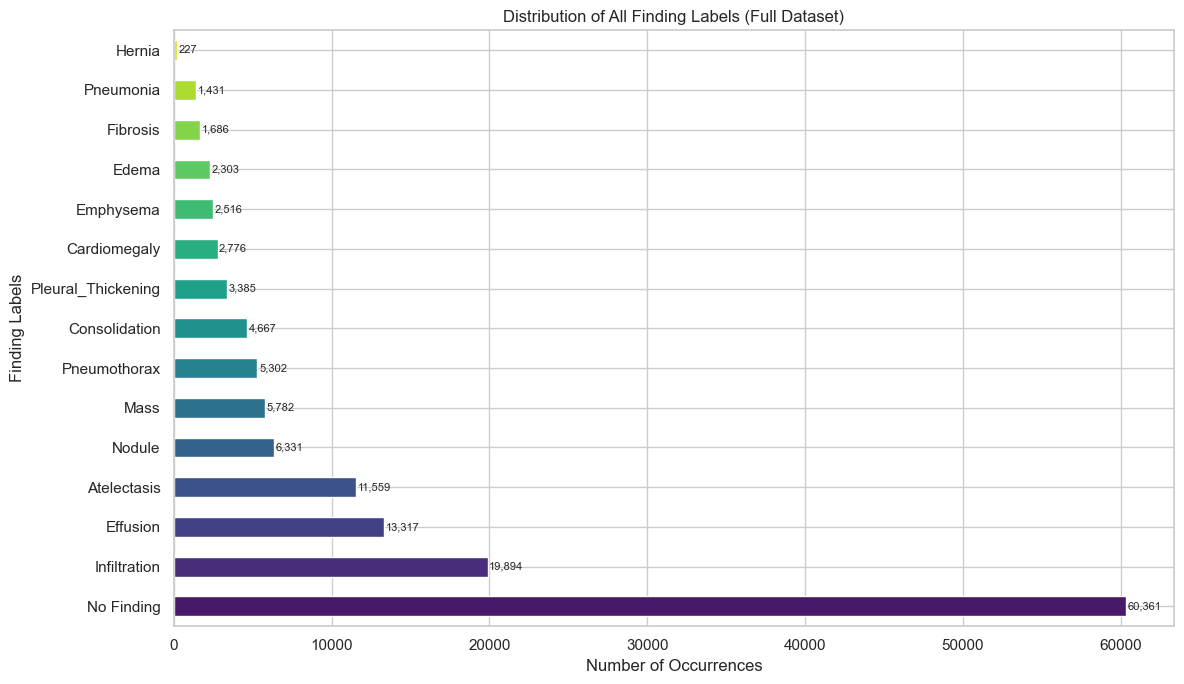

In [38]:
if df_meta is not None:
    all_labels = df_meta['Finding Labels'].str.split('|').explode()
    label_counts = all_labels.value_counts()

    fig, ax = plt.subplots(figsize=(12, 7))
    label_counts.plot(kind='barh', ax=ax,
                      color=sns.color_palette('viridis', len(label_counts)))
    ax.set_title('Distribution of All Finding Labels (Full Dataset)')
    ax.set_xlabel('Number of Occurrences')
    for i, v in enumerate(label_counts.values):
        ax.text(v + 100, i, f'{v:,}', va='center', fontsize=8)
    plt.tight_layout()
    plt.savefig(EDA_OUTPUT / 'pathology_distribution.png',
                dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('NIH metadata not available — skipping pathology chart.')

## 5 — Patient-Level Analysis

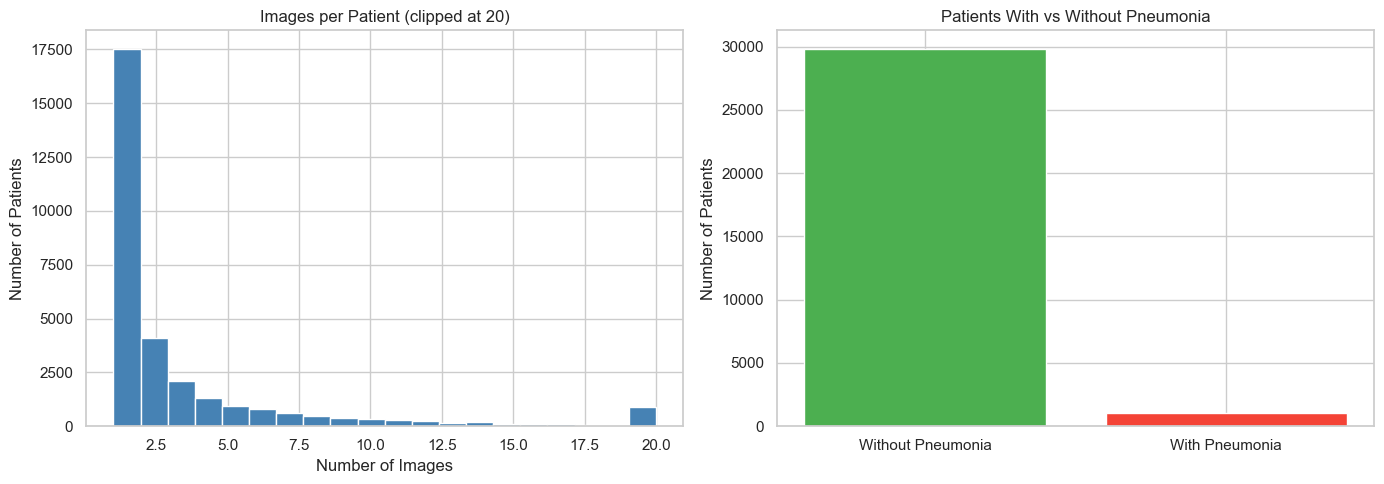

Total patients       : 30,805
Patients w/ Pneumonia: 1,008
Avg images/patient   : 3.64


In [39]:
if df_meta is not None:
    images_per_patient = df_meta.groupby('Patient ID').size()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    clipped = images_per_patient.clip(upper=20)
    ax.hist(clipped, bins=20, color='steelblue', edgecolor='white')
    ax.set_title('Images per Patient (clipped at 20)')
    ax.set_xlabel('Number of Images')
    ax.set_ylabel('Number of Patients')

    ax = axes[1]
    pneu_patients = df_meta[
        df_meta['Finding Labels'].str.contains('Pneumonia', na=False)
    ]['Patient ID'].nunique()
    total_patients = df_meta['Patient ID'].nunique()
    ax.bar(['Without Pneumonia', 'With Pneumonia'],
           [total_patients - pneu_patients, pneu_patients],
           color=['#4CAF50', '#F44336'])
    ax.set_title('Patients With vs Without Pneumonia')
    ax.set_ylabel('Number of Patients')

    plt.tight_layout()
    plt.savefig(EDA_OUTPUT / 'patient_analysis.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Total patients       : {total_patients:,}')
    print(f'Patients w/ Pneumonia: {pneu_patients:,}')
    print(f'Avg images/patient   : {images_per_patient.mean():.2f}')

## 6 — Demographic Analysis

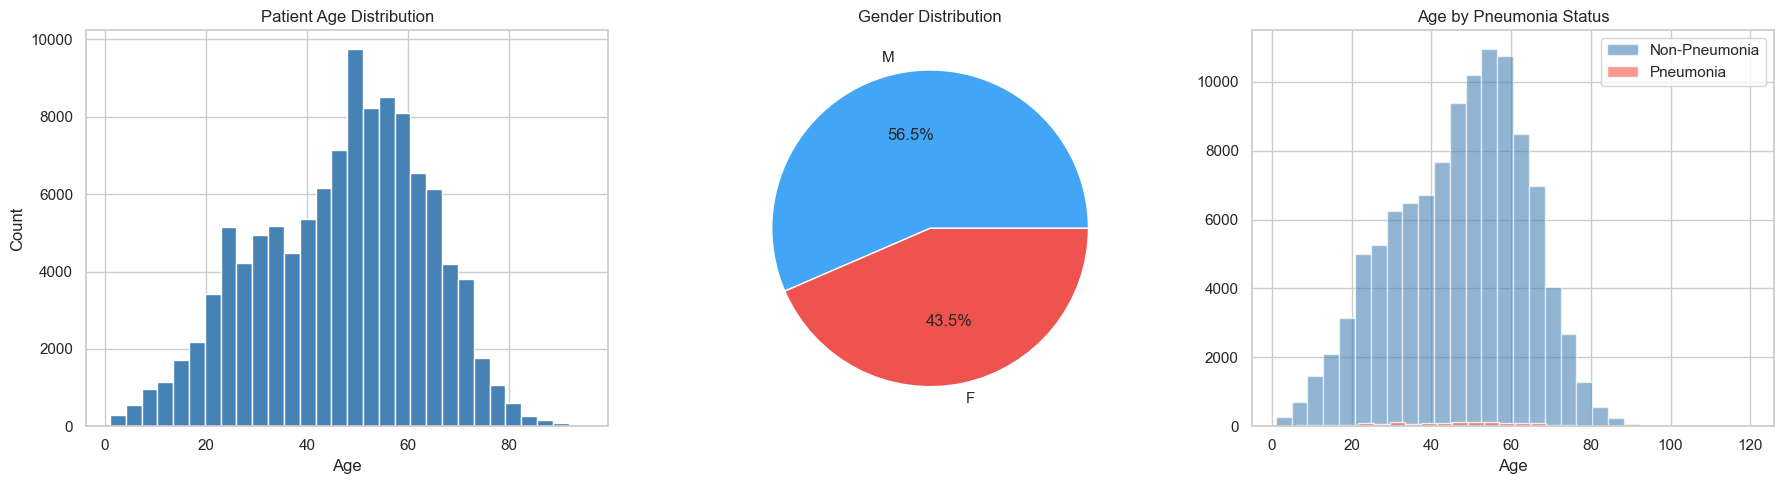

In [40]:
if df_meta is not None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Age distribution
    ax = axes[0]
    valid_ages = df_meta['Patient Age'][
        (df_meta['Patient Age'] > 0) & (df_meta['Patient Age'] < 120)
    ]
    ax.hist(valid_ages, bins=30, color='steelblue', edgecolor='white')
    ax.set_title('Patient Age Distribution')
    ax.set_xlabel('Age')
    ax.set_ylabel('Count')

    # Gender distribution
    ax = axes[1]
    gender_counts = df_meta['Patient Gender'].value_counts()
    ax.pie(gender_counts.values,
           labels=gender_counts.index,
           autopct='%1.1f%%',
           colors=['#42A5F5','#EF5350'])
    ax.set_title('Gender Distribution')

    # Age by pneumonia status
    ax = axes[2]
    pos_ages = df_meta[
        df_meta['Finding Labels'].str.contains('Pneumonia', na=False)
    ]['Patient Age']
    neg_ages = df_meta[
        ~df_meta['Finding Labels'].str.contains('Pneumonia', na=False)
    ]['Patient Age']
    ax.hist(neg_ages.clip(0,120), bins=30,
            alpha=0.6, label='Non-Pneumonia', color='steelblue')
    ax.hist(pos_ages.clip(0,120), bins=30,
            alpha=0.8, label='Pneumonia', color='salmon')
    ax.set_title('Age by Pneumonia Status')
    ax.set_xlabel('Age')
    ax.legend()

    plt.tight_layout()
    plt.savefig(EDA_OUTPUT / 'demographics.png',
                dpi=150, bbox_inches='tight')
    plt.show()

## 7 — View Position Analysis

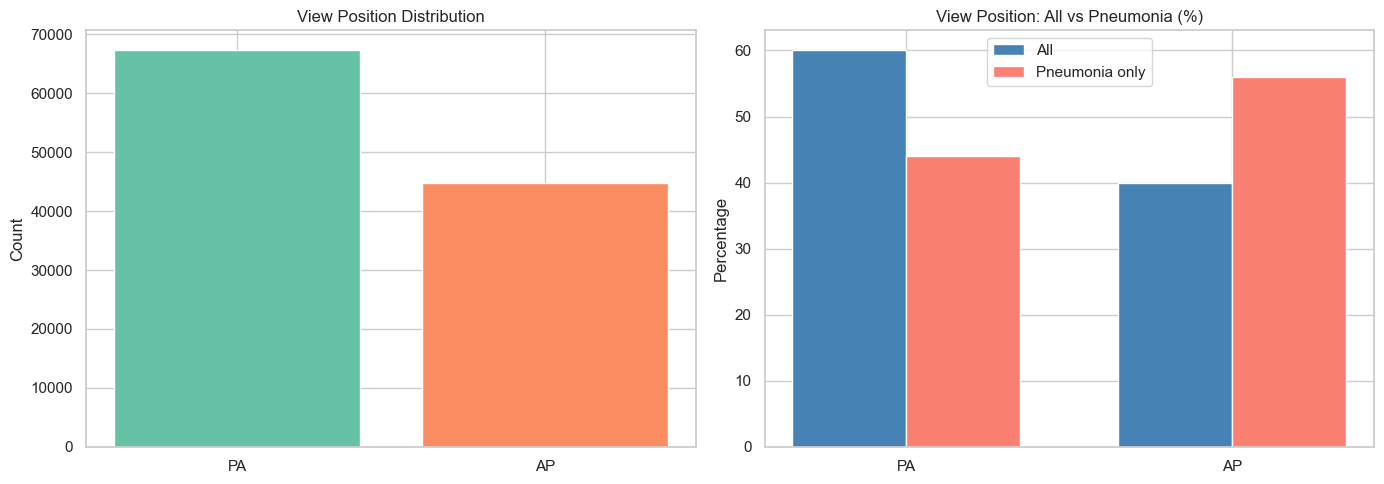

In [41]:
if df_meta is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    vp_counts = df_meta['View Position'].value_counts()
    ax.bar(vp_counts.index, vp_counts.values,
           color=sns.color_palette('Set2', len(vp_counts)))
    ax.set_title('View Position Distribution')
    ax.set_ylabel('Count')

    ax = axes[1]
    pneu_view = df_meta[
        df_meta['Finding Labels'].str.contains('Pneumonia', na=False)
    ]['View Position'].value_counts(normalize=True) * 100
    all_view = df_meta['View Position'].value_counts(normalize=True) * 100
    x = np.arange(len(all_view))
    w = 0.35
    ax.bar(x - w/2, all_view.values, w, label='All', color='steelblue')
    ax.bar(x + w/2,
           [pneu_view.get(v, 0) for v in all_view.index],
           w, label='Pneumonia only', color='salmon')
    ax.set_xticks(x)
    ax.set_xticklabels(all_view.index)
    ax.set_title('View Position: All vs Pneumonia (%)')
    ax.set_ylabel('Percentage')
    ax.legend()

    plt.tight_layout()
    plt.savefig(EDA_OUTPUT / 'view_position.png',
                dpi=150, bbox_inches='tight')
    plt.show()

## 8 — Sample Image Visualization

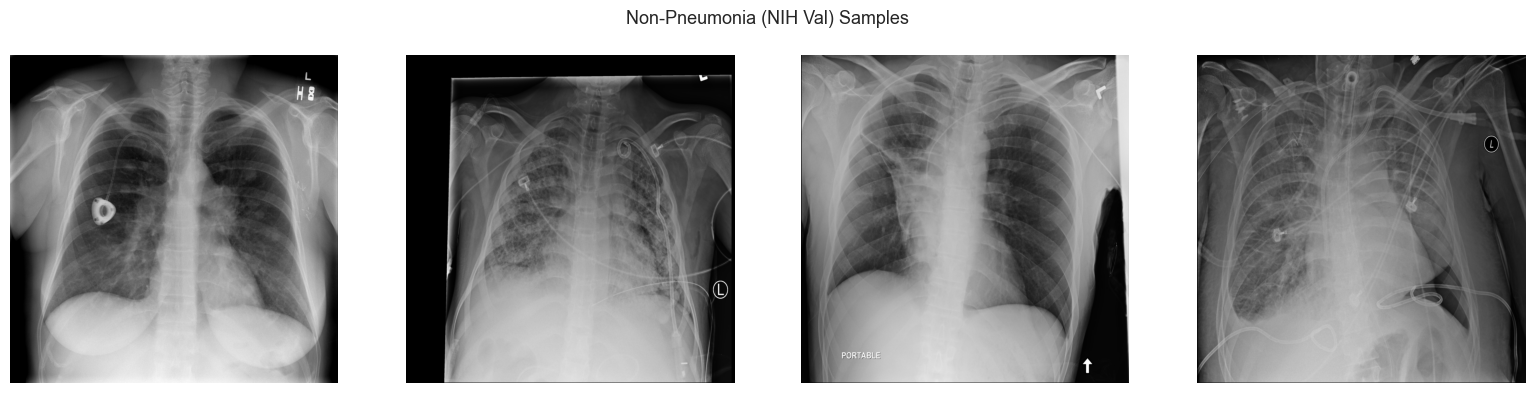

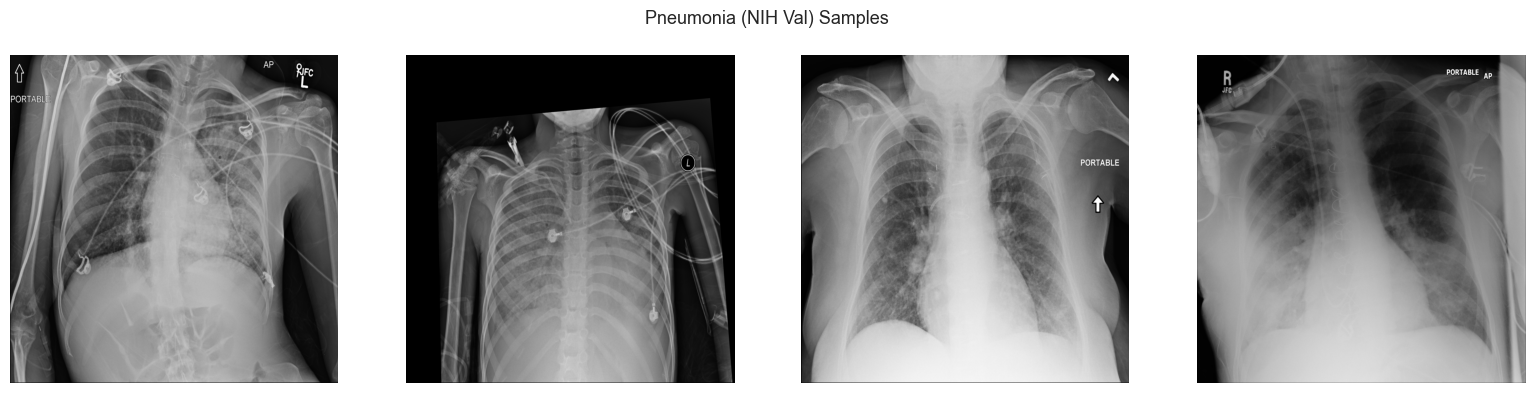

Sample images saved.


In [42]:
def show_samples(df, label_val, label_name, n=4):
    subset  = df[df['target_pneumonia'] == label_val]
    samples = subset.sample(min(n, len(subset)), random_state=42)
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    fig.suptitle(f'{label_name} Samples', fontsize=13)
    for ax, (_, row) in zip(axes, samples.iterrows()):
        p = row.get('image_path', None)
        if p and Path(p).exists():
            img = Image.open(p).convert('RGB')
            ax.imshow(img, cmap='gray')
        else:
            ax.text(0.5, 0.5, 'Image\nnot found',
                    ha='center', va='center', transform=ax.transAxes)
        ax.axis('off')
    plt.tight_layout()
    return fig

try:
    # Use val since it has real NIH images
    fig_neg = show_samples(df_val, 0, 'Non-Pneumonia (NIH Val)')
    fig_neg.savefig(EDA_OUTPUT / 'sample_non_pneumonia.png',
                    dpi=150, bbox_inches='tight')
    plt.show()

    fig_pos = show_samples(df_val, 1, 'Pneumonia (NIH Val)')
    fig_pos.savefig(EDA_OUTPUT / 'sample_pneumonia.png',
                    dpi=150, bbox_inches='tight')
    plt.show()
    print('Sample images saved.')
except Exception as e:
    print(f'Could not display images: {e}')

## 9 — Training Set Source & Weight Analysis

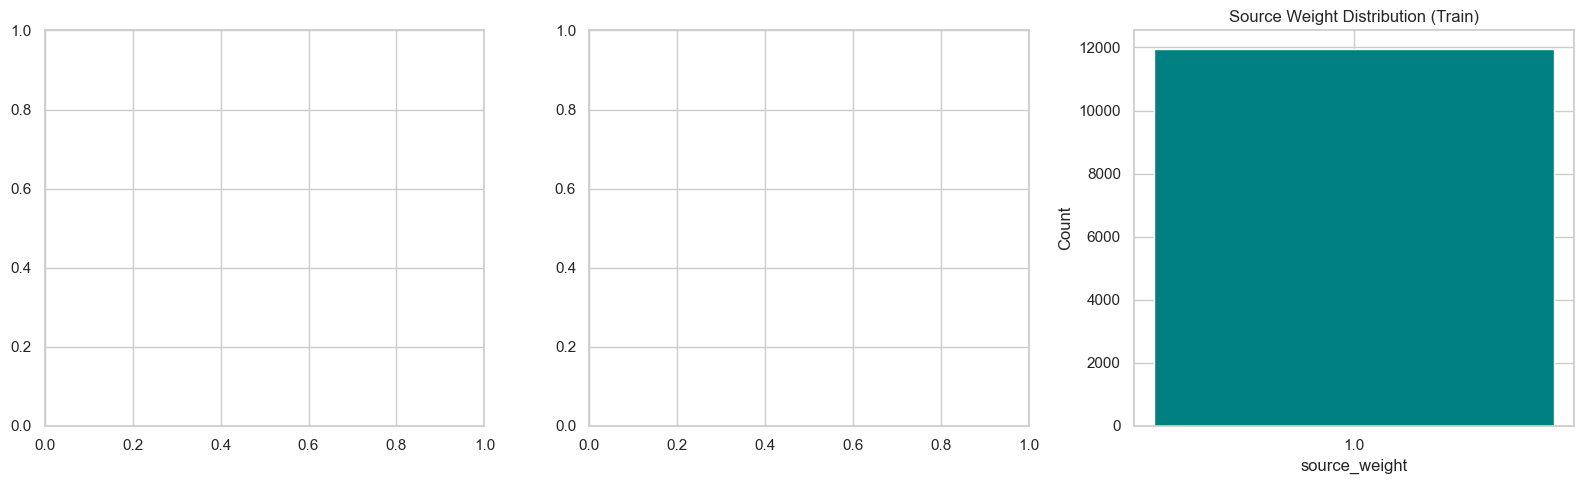

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Source distribution
ax = axes[0]
if 'source' in df_train.columns:
    src_counts = df_train.groupby(['source','target_pneumonia']).size().unstack(fill_value=0)
    src_counts.plot(kind='bar', ax=ax, color=['steelblue','salmon'])
    ax.set_title('Training Source Distribution')
    ax.set_xlabel('Source')
    ax.set_ylabel('Count')
    ax.legend(['Non-Pneumonia','Pneumonia'])
    ax.tick_params(axis='x', rotation=0)

# Negative type breakdown
ax = axes[1]
if 'negative_type' in df_train.columns:
    neg_df = df_train[df_train['target_pneumonia'] == 0]
    neg_type_counts = neg_df['negative_type'].value_counts()
    ax.bar(neg_type_counts.index, neg_type_counts.values, color='coral')
    ax.set_title('Negative Sample Types (Train)')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=15)

# Source weight distribution
ax = axes[2]
if 'source_weight' in df_train.columns:
    weight_counts = df_train['source_weight'].value_counts().sort_index()
    ax.bar([str(w) for w in weight_counts.index],
           weight_counts.values, color='teal')
    ax.set_title('Source Weight Distribution (Train)')
    ax.set_xlabel('source_weight')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig(EDA_OUTPUT / 'training_source_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 10 — Val Contamination Analysis

> **Note:** Val Contamination Analysis is obsolete. The new canonical splits generated by `scripts/rebuild_clean_splits.py` are strictly binary and 100% clean.

## 11 — EDA Summary

In [44]:
df_train = pd.read_csv(DATA_SPLITS / 'train.csv')
df_val   = pd.read_csv(DATA_SPLITS / 'val.csv')
df_test  = pd.read_csv(DATA_SPLITS / 'test.csv')

# Normalize column names
for _df in [df_train, df_val, df_test]:
    if 'label' in _df.columns and 'target_pneumonia' not in _df.columns:
        _df['target_pneumonia'] = _df['label']
    if 'patient_id' not in _df.columns and 'pid_str' in _df.columns:
        _df['patient_id'] = _df['pid_str']

df_all   = pd.concat([df_train, df_val, df_test], ignore_index=True)
print(f'Total dataset: {len(df_all):,} images')
print(f'Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}')


Total dataset: 17,172 images
Train: 11,943 | Val: 2,611 | Test: 2,618
